## Exercice 1 : Analyse exploratoire des données

### Instructions
Charger les données à partir des fichiers CSV : **DONE**
Supprimer la colonne cible des données d'entraînement
Séparer les données en groupes train/test
Comprendre les données

1 . Charger les données à partir des fichiers CSV

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Charger les données
train = pd.read_csv('/content/sample_data/california_housing_train.csv')
test = pd.read_csv('/content/sample_data/california_housing_test.csv')

print("Shape du train :", train.shape)
print("Shape du test  :", test.shape)

print("\nColonnes du train :", train.columns.tolist())
print("\nFirst 5 rows of train_df:")
display(train.head())
print("\nFirst 5 rows of test_df:")
display(test.head())

Shape du train : (17000, 9)
Shape du test  : (3000, 9)

Colonnes du train : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

First 5 rows of train_df:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0



First 5 rows of test_df:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


2 .Supprimer la colonne cible des données d'entraînement

In [13]:
# Supposons que la colonne cible s'appelle 'target', 'y', 'label', 'price', etc.
# Remplacez 'target' par le nom réel de votre variable cible

target_col = 'median_house_value'  # ← À adapter selon votre dataset

y_train = train[target_col].copy()
X_train = train.drop(columns=[target_col], errors='ignore')

print(f"Variable cible supprimée : {target_col}")
print("Shape X_train :", X_train.shape)
print("Shape y_train :", y_train.shape)

Variable cible supprimée : median_house_value
Shape X_train : (17000, 8)
Shape y_train : (17000,)


3 . Séparer les données en groupes train/test

In [14]:
from sklearn.model_selection import train_test_split

# Division stratifiée (si classification) ou aléatoire
X_train_split, X_valid, y_train_split, y_valid = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train if y_train.dtype == 'object' or y_train.nunique() < 20 else None
)

print("Après split :")
print("X_train_split :", X_train_split.shape)
print("X_valid       :", X_valid.shape)

Après split :
X_train_split : (13600, 8)
X_valid       : (3400, 8)


4 . Comprendre les données

In [15]:
# Informations générales
print("\n=== Infos générales ===")
print(X_train.info())
print("\n=== Statistiques descriptives ===")
print(X_train.describe(include='all'))

# Valeurs manquantes
missing = X_train.isnull().sum()
print("\n=== Valeurs manquantes ===")
print(missing[missing > 0].sort_values(ascending=False))

# Types de variables
print("\n=== Types de variables ===")
print(X_train.dtypes.value_counts())

# Analyse univariée + bivariée
# Exemples :
numeric_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

print(f"Variables numériques : {len(numeric_cols)}")
print(f"Variables catégorielles : {len(cat_cols)}")


=== Infos générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
dtypes: float64(8)
memory usage: 1.0 MB
None

=== Statistiques descriptives ===
          longitude      latitude  housing_median_age   total_rooms  \
count  17000.000000  17000.000000        17000.000000  17000.000000   
mean    -119.562108     35.625225           28.589353   2643.664412   
std        2.005166      2.137340           12.586937   2179.947071   
min     -124.

Visualisations recommandées

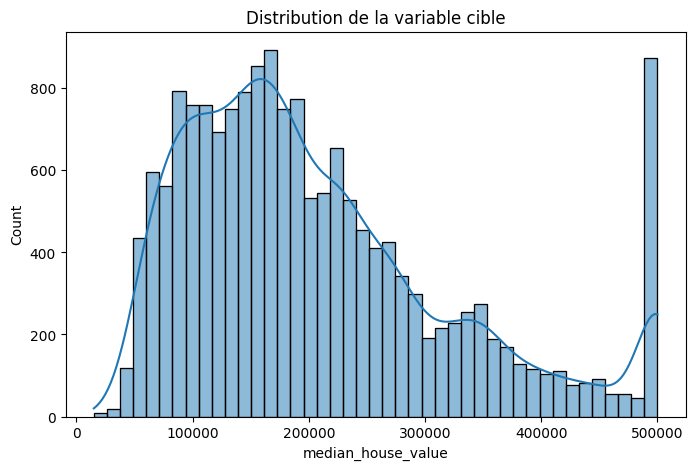

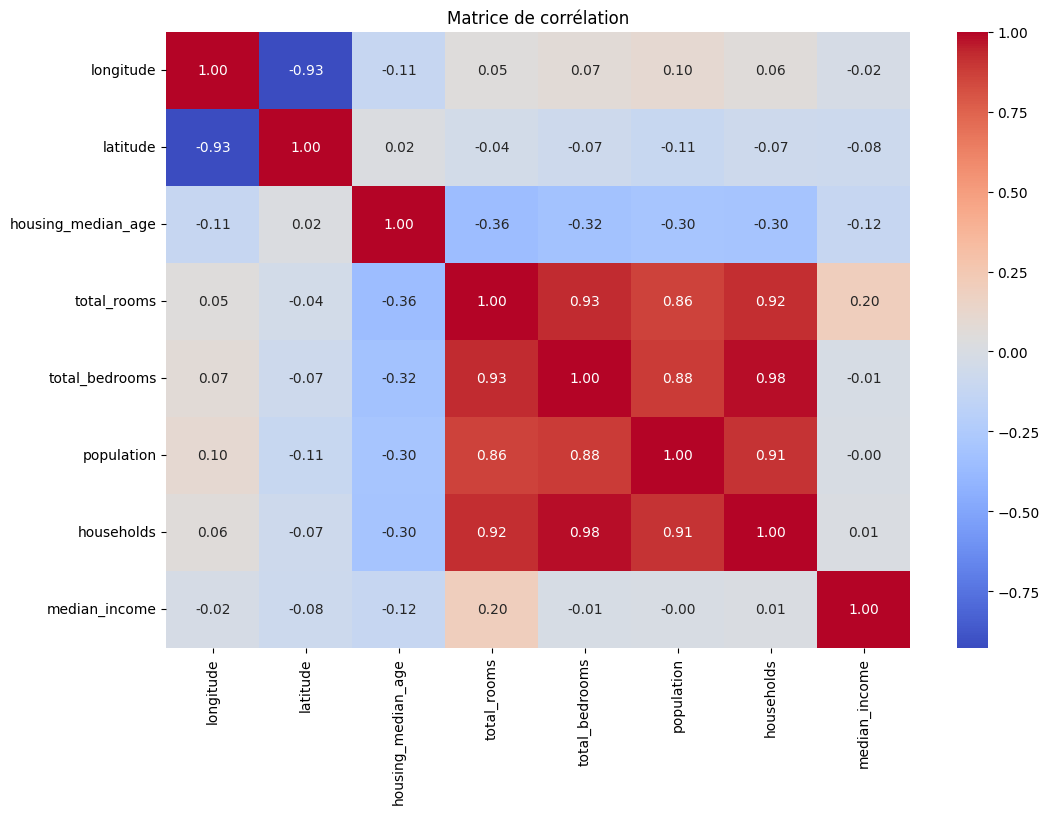

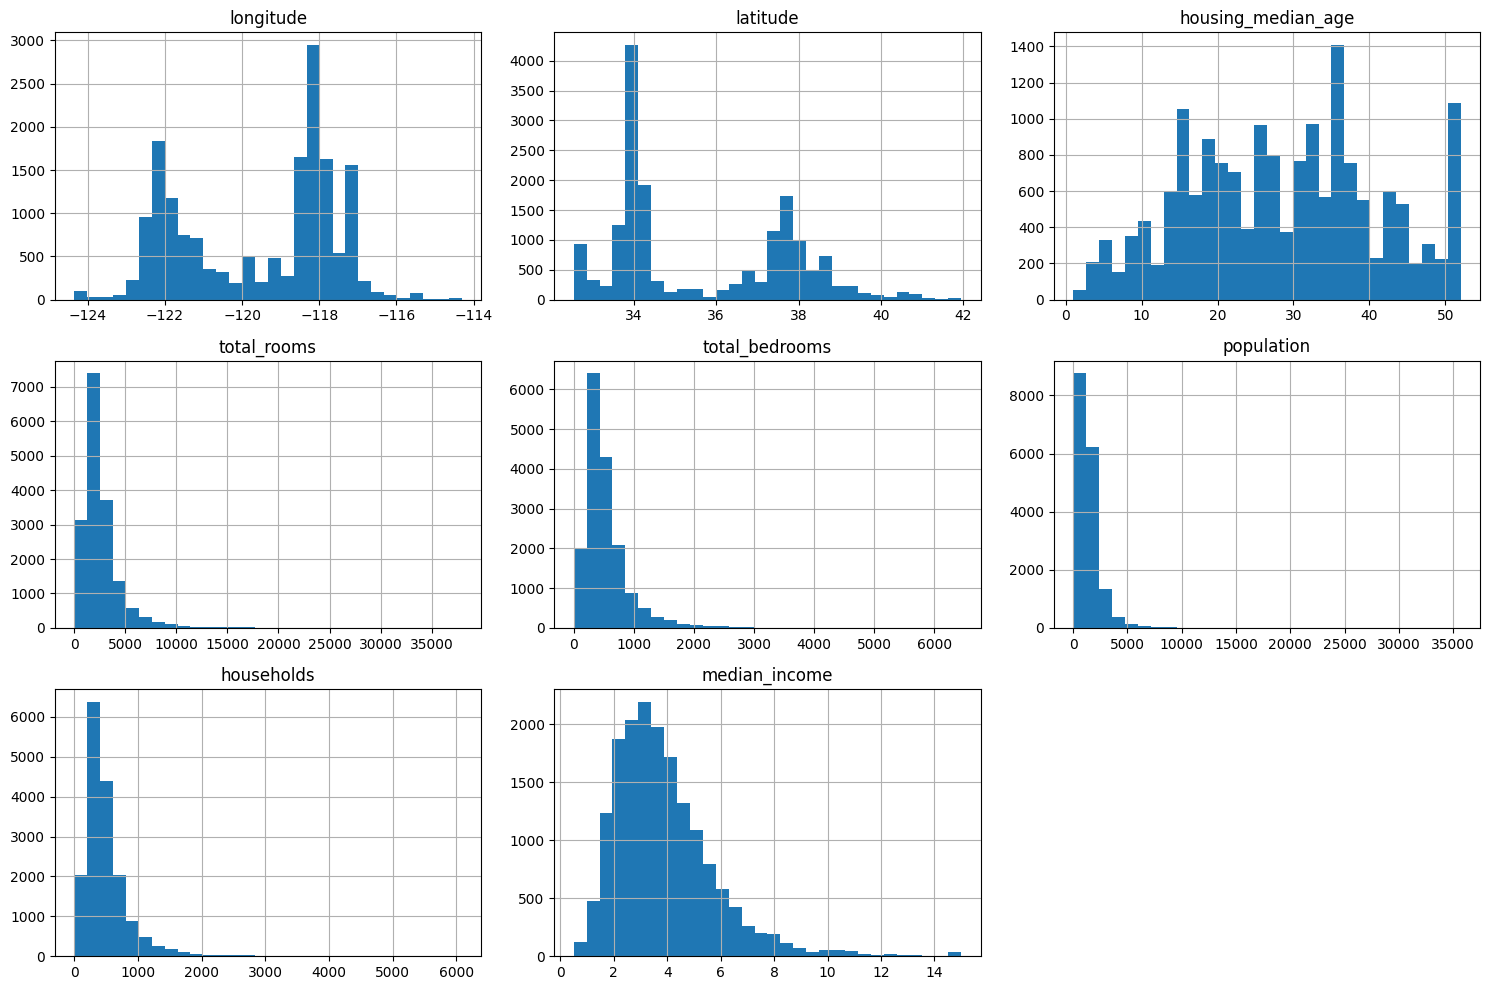

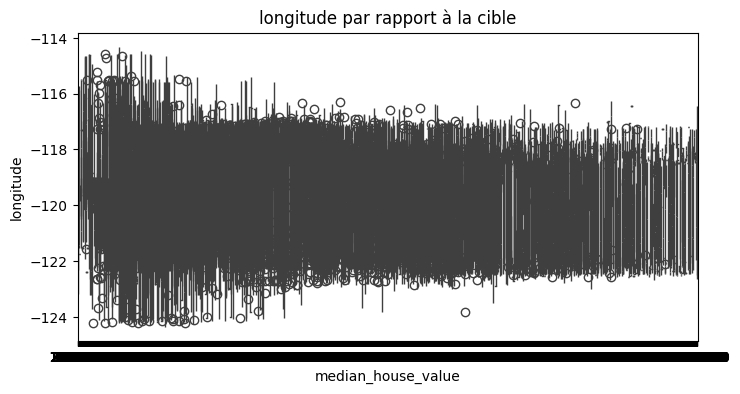

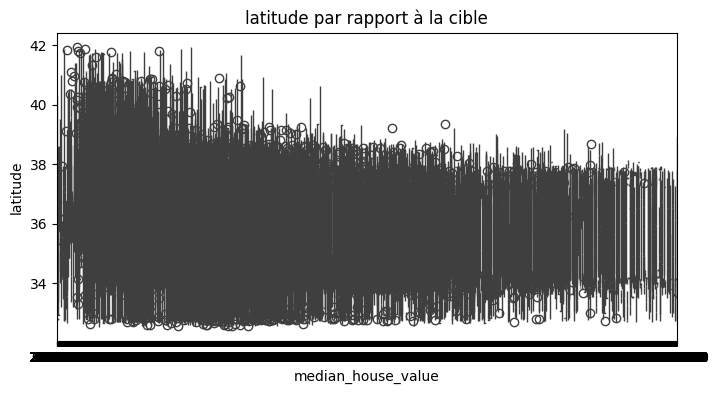

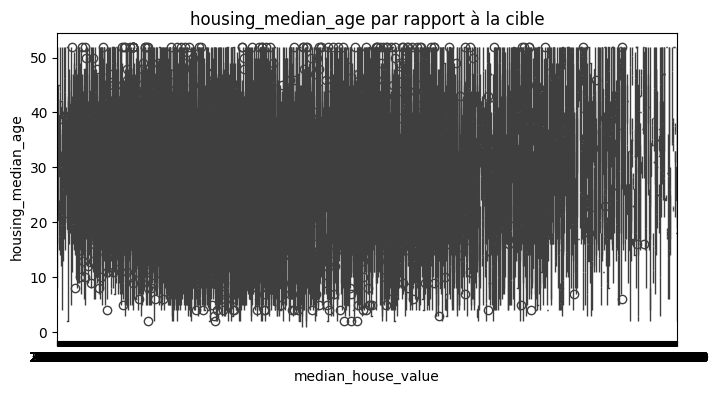

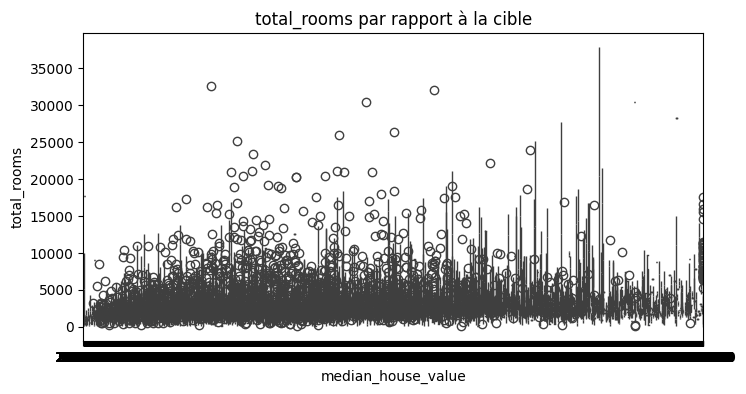

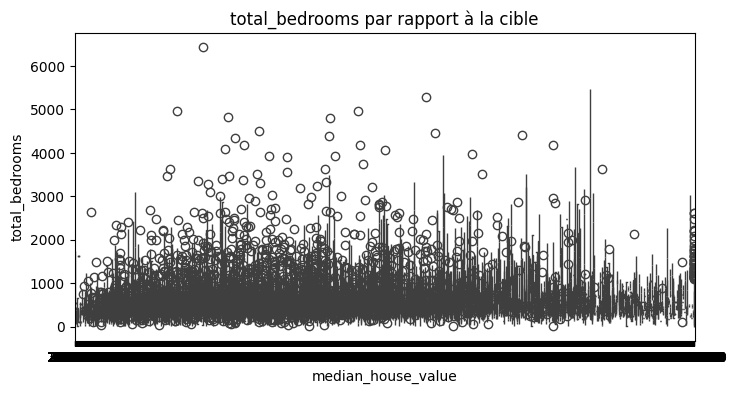

In [16]:
# Distribution de la cible
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train) if y_train.dtype == 'object' else sns.histplot(y_train, kde=True)
plt.title('Distribution de la variable cible')
plt.show()

# Matrice de corrélation (variables numériques)
plt.figure(figsize=(12, 8))
sns.heatmap(X_train[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()

# Distributions numériques
X_train[numeric_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Boxplots (pour détecter outliers)
for col in numeric_cols[:5]:  # Limiter pour ne pas surcharger
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=y_train, y=X_train[col])
    plt.title(f'{col} par rapport à la cible')
    plt.show()


Exercice 2 : Régression logistique sans recherche par grille

Instructions

Utilisez l'ensemble de données pour construire un modèle de régression logistique sans recourir à une recherche exhaustive. Divisez les données en ensembles d'entraînement et de test, puis entraînez le modèle de régression logistique et évaluez ses performances sur l'ensemble de test.



In [17]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import joblib


In [23]:

# Charger les données
data = load_breast_cancer()
X = data.data
y = data.target

# Diviser en ensembles d'entraînement et de test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mise à l'échelle des features (fortement recommandé pour la régression logistique)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entraîner le modèle sans GridSearchCV
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Évaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nMatrice de confusion:\n", conf_matrix)
print("\nRapport de classification:\n", report)

# Sauvegarde du modèle
# Changed the path to save the model to a directory that exists in Colab
joblib.dump(model, '/content/logistic_model.pkl')
print("\nModèle sauvegardé à /content/logistic_model.pkl.")

Accuracy: 0.9736842105263158

Matrice de confusion:
 [[41  2]
 [ 1 70]]

Rapport de classification:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Modèle sauvegardé à /content/logistic_model.pkl.


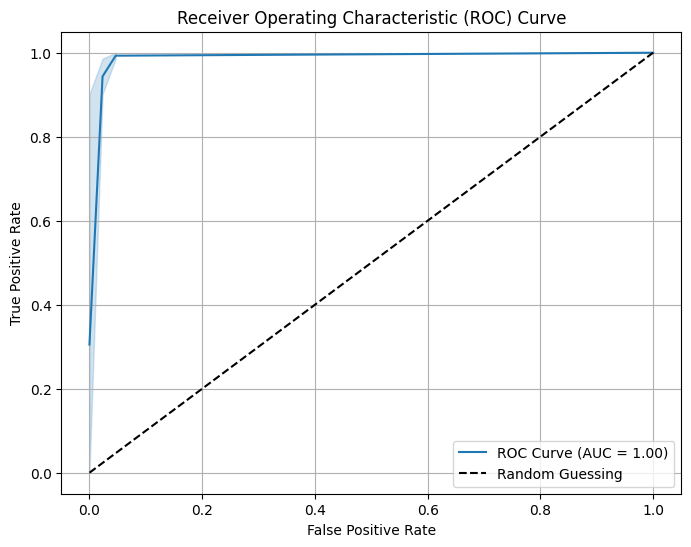

In [32]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr, y=tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Résultats sur l'ensemble de test
    . Accuracy : 0.9737 (97.37%)
    



Exercice 3 : Régression logistique avec recherche par grille

Instructions

Construisez un modèle de régression logistique à l'aide de l'ensemble de données, mais cette fois-ci, utilisez GridSearchCV pour optimiser les hyperparamètres tels que C et la pénalité.

In [34]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [35]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Chargement des données
iris = load_iris()
X = iris.data
y = iris.target

# Division en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Grille d'hyperparamètres
param_grid = [
    {'C': [0.1, 1, 10, 100], 'penalty': ['l1'], 'solver': ['saga']},
    {'C': [0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['saga']},
    {'C': [0.1, 1, 10, 100], 'penalty': ['elasticnet'],
     'solver': ['saga'], 'l1_ratio': [0.25, 0.5, 0.75]},
    {'C': [0.1, 1, 10, 100], 'penalty': [None], 'solver': ['saga']}
]

# Modèle avec recherche par grille
logreg = LogisticRegression(max_iter=5000, random_state=42)
grid_search = GridSearchCV(
    logreg,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Résultats
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score de validation croisée :", round(grid_search.best_score_, 4))

# Évaluation sur le jeu de test
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nAccuracy sur le test :", round(accuracy_score(y_test, y_pred), 4))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Meilleurs paramètres : {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
Meilleur score de validation croisée : 0.975

Accuracy sur le test : 1.0

Rapport de classification :
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Exercice 4 : SVM sans recherche par grille

Instructions

Entraînez un classificateur SVM (Support Vector Machine) sur l'ensemble de données sans utiliser de recherche par grille. Choisissez un noyau approprié et définissez manuellement les hyperparamètres.



In [37]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [36]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Chargement des données
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 2. Division train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Standardisation (très importante pour SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Création du modèle SVM avec hyperparamètres choisis manuellement
# Choix du noyau : RBF (Radial Basis Function) → souvent le plus performant sur Iris
svm_model = SVC(
    kernel='rbf',      # Noyau gaussien (très adapté aux données non linéaires)
    C=1.0,             # Paramètre de régularisation (équilibre marge/erreurs)
    gamma='scale',     # gamma = 1 / (n_features * X.var()) → bon choix par défaut
    random_state=42
)

# 5. Entraînement
svm_model.fit(X_train, y_train)

# 6. Prédictions
y_pred = svm_model.predict(X_test)

# 7. Évaluation
print("=== Résultats SVM (noyau RBF) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}\n")
print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

=== Résultats SVM (noyau RBF) ===
Accuracy : 0.9333

Rapport de classification :
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

Matrice de confusion :
[[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]


Exercice 5 : SVM avec recherche par grille

Instructions

Implémentez un classificateur SVM sur l'ensemble de données avec GridSearchCV pour trouver la meilleure combinaison des hyperparamètres C, noyau et gamma.



In [39]:
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [38]:
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Chargement du dataset Iris
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modèle SVM
svc = SVC()

# Grille d'hyperparamètres
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

# GridSearchCV
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Résultats
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score CV :", grid_search.best_score_)

# Évaluation finale
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred))
print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Meilleurs paramètres : {'C': 0.1, 'gamma': 0.1, 'kernel': 'poly'}
Meilleur score CV : 0.9583333333333334

Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Matrice de confusion :
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Exercice 6 : XGBoost sans recherche par grille

Instructions

Utilisez l'ensemble de données pour entraîner un classificateur XGBoost sans optimisation des hyperparamètres. Définissez les hyperparamètres manuellement et justifiez vos choix.

Choix du dataset

Comme aucun dataset n'est fourni explicitement dans la requête, j'utilise le Breast Cancer Wisconsin dataset (disponible via scikit-learn), un dataset de classification binaire classique très utilisé dans les tutoriels XGBoost (diagnostic malin/bénin). Il est adapté pour illustrer l'exercice.
Si vous avez un dataset spécifique (par ex. churn, titanic, etc.), remplacez-le dans le code.

Justification des hyperparamètres (choix manuels)

Sans GridSearchCV ou RandomizedSearchCV, on règle manuellement en se basant sur des bonnes pratiques standards pour XGBoost :
n_estimators=100 : Nombre d'arbres raisonnable pour démarrer. Suffisant pour la convergence sans trop de temps de calcul ni overfitting majeur sur des datasets de taille moyenne.
max_depth=5 : Profondeur modérée. Permet de capturer des interactions complexes sans sur-apprendre (valeur par défaut souvent 6 ; 3-6 est un bon départ manuel).
learning_rate=0.1 : Taux d'apprentissage classique. Équilibre entre vitesse de convergence et stabilité (valeurs plus basses comme 0.01 nécessitent plus d'arbres ; 0.3 est plus agressif).
subsample=0.8 : Sous-échantillonnage des observations (80 %) pour ajouter de la régularisation et réduire l'overfitting.
colsample_bytree=0.8 : Sous-échantillonnage des features par arbre (80 %) pour plus de diversité et robustesse.
objective='binary:logistic' et eval_metric='logloss' : Adaptés à la classification binaire.
random_state=42 : Pour la reproductibilité.
Ces choix sont conservateurs et "sûrs" pour un premier modèle sans tuning. Ils proviennent de recommandations courantes (documentation XGBoost, Kaggle, DataCamp, etc.). On peut ensuite évaluer et ajuster itérativement.

In [40]:
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

In [41]:
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# 1. Chargement des données
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malin, 1 = bénin (classification binaire)

print("Shape des données:", X.shape)
print("Classes:", pd.Series(y).value_counts())

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Création du modèle XGBoost avec hyperparamètres manuels
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False  # Option obsolète selon versions récentes
)

# 4. Entraînement
xgb_clf.fit(X_train, y_train)

# 5. Prédictions et évaluation
y_pred = xgb_clf.predict(X_test)

print("\n=== Résultats ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report :\n", classification_report(y_test, y_pred))
print("\nMatrice de confusion :\n", confusion_matrix(y_test, y_pred))

# Feature importance (optionnel)
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_clf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop 5 features importantes :\n", importances.head())

Shape des données: (569, 30)
Classes: 1    357
0    212
Name: count, dtype: int64

=== Résultats ===
Accuracy : 0.9649122807017544

Classification Report :
               precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Matrice de confusion :
 [[39  3]
 [ 1 71]]

Top 5 features importantes :
                  feature  importance
22       worst perimeter    0.249455
7    mean concave points    0.164263
20          worst radius    0.089779
23            worst area    0.088895
27  worst concave points    0.069910


Comment exécuter

Installez les bibliothèques si nécessaire : pip install xgboost scikit-learn pandas
Exécutez le script dans un notebook Jupyter ou un fichier .py.

Améliorations possibles (sans grid search)

Utiliser early_stopping_rounds avec un eval_set pour arrêter l'entraînement automatiquement.
Ajouter gamma, reg_alpha, reg_lambda pour plus de régularisation.
Tester différentes valeurs une par une (par ex. learning_rate = [0.05, 0.1, 0.3]).

Exercice 7 : XGBoost avec recherche par grille

Instructions

Entraînez un classificateur XGBoost sur l'ensemble de données en utilisant GridSearchCV pour optimiser les hyperparamètres tels que learning_rate, n_estimators, max_depth, etc.



Voici une implémentation complète et fonctionnelle en Python qui entraîne un classificateur XGBoost sur le jeu de données Iris (standard pour les exercices de classification multiclasse) en utilisant GridSearchCV pour optimiser les hyperparamètres.

In [43]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


In [42]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Charger les données
iris = load_iris()
X = iris.data
y = iris.target

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Classificateur XGBoost
xgb_clf = xgb.XGBClassifier(objective='multi:softprob', random_state=42, eval_metric='mlogloss')

# Grille d'hyperparamètres
param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],           # Correction : max_depth (et non max_deep)
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Entraînement de XGBoost avec GridSearchCV...")
grid_search.fit(X_train, y_train)

# Résultats
print("\nMeilleurs hyperparamètres :", grid_search.best_params_)
print(f"Meilleur score CV : {grid_search.best_score_:.4f}")

# Évaluation finale
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print(f"Précision sur le test : {accuracy_score(y_test, y_pred):.4f}")

Entraînement de XGBoost avec GridSearchCV...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Meilleurs hyperparamètres : {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 1.0}
Meilleur score CV : 0.9583

Rapport de classification :
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Précision sur le test : 1.0000
